# Project 2.5 — System Identification of a Nonlinear Dynamical System

**Course:** Machine Learning for Vision and Multimedia (Polito, 2025/26) — project §2.5.
**Dataset:** Cortical Responses Evoked by Wrist Joint Manipulation (Vlaar et al., IEEE TNSRE 2018).

Goal: identify a SISO model `y[k] = f(u[·], y[·])` relating the wrist handle angle (`u`) to the top-SNR ICA component of the EEG (`y`).

* **Phase 1** — train NNARX, simple RNN, LSTM, GRU.
* **Phase 2** — sweep architecture sizes (hidden size, layers).
* **Phase 3** — compare simulation accuracy, training time, parameter count, FLOPs/sample.

Two datasets are supported via `CFG["dataset"]`:
* `"small"` — pre-averaged, downsampled, scaled, time-delayed (`Benchmark_EEG_small/Benchmark_EEG_small.mat`).
* `"medium"` — raw `[M, P, N_raw]` per subject; the notebook reproduces the small-version preprocessing in Python (`Benchmark_EEG_medium/Benchmark_EEG_medium.mat`).

Two splits are supported via `CFG["split"]`:
* `"within"` — within-participant holdout by realization index.
* `"loso"` — leave-one-subject-out: one subject is fully held out for test, realizations of the remaining subjects supply train + val.

## 1. Imports and device

In [57]:
import os, json, time, math, random
from pathlib import Path

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE, "| torch:", torch.__version__)

device: cuda | torch: 2.10.0+cu128


## 2. Configuration

All hyperparameters in one dict so Phase 2 sweeps are just copies of this with values changed.

In [58]:
CFG = {
    "fs": 256,                 # sample rate (Hz) after downsampling
    # Dataset + split
    "dataset": "medium",       # "small" | "medium"
    "split":   "loso",         # "within" | "loso"
    # NNARX regressor sizes (nu/ny used only when narx_*_taps is None)
    "narx_nu": 8,
    "narx_ny": 7,
    # Explicit lag taps (dilated). None -> consecutive 0..nu-1 / 1..ny.
    "narx_u_taps": (0, 1, 2, 4, 8, 16, 32, 64),
    "narx_y_taps": (1, 2, 4, 8, 16, 32, 64),
    "narx_hidden": (64, 64),  # MLP hidden widths
    # NNARX architecture / parameterization
    "narx_act":             "gelu",
    "narx_dropout":         0.1,
    "narx_skip":            True,
    "narx_residual":        True,
    "narx_u_feats":         ("du",),
    # NNARX training-time robustness
    "narx_y_noise_std":     0.05,
    "narx_val_every":       2,
    "narx_patience_checks": 8,
    "narx_weight_decay":    1e-4,
    "narx_grad_clip":       1.0,
    # smoother curriculum: small jumps between phases keeps the loss surface stable
    "narx_kstep_schedule":  ((0, 1), (15, 5), (30, 10), (50, 20), (80, 40), (120, 80)),
    "narx_lr_schedule":     "cosine",
    "narx_ensemble":        3,
    "narx_spec_lambda":     0.1,
    "narx_spec_kstep_min":  16,
    # Curriculum-advance stabilizers (kick in only when kstep changes)
    "narx_curriculum_lr_drop": 0.5,    # multiply LR by this on each k advance (warm restart)
    "narx_curriculum_restore": True,   # reload best-so-far weights at each k advance
    "narx_step_decay":         1.0,    # geometric loss weighting w_j = step_decay**j (1.0 = off)
    # Recurrent models
    "rec_hidden": 64,
    "rec_layers": 1,
    # Training
    "epochs_narx": 200,
    "epochs_rec": 200,
    "batch_narx": 512,
    "lr": 1e-3,
    "weight_decay": 0.0,
    # Within-participant split (indices into M=7 realizations per participant)
    "train_real_idx": [0, 1, 2, 3, 4],
    "val_real_idx":   [5],
    "test_real_idx":  [6],
    # LOSO split
    "loso_test_subject":  0,
    "loso_val_real_idx":  [5, 6],
}
CFG

{'fs': 256,
 'dataset': 'medium',
 'split': 'loso',
 'narx_nu': 8,
 'narx_ny': 7,
 'narx_u_taps': (0, 1, 2, 4, 8, 16, 32, 64),
 'narx_y_taps': (1, 2, 4, 8, 16, 32, 64),
 'narx_hidden': (64, 64),
 'narx_act': 'gelu',
 'narx_dropout': 0.1,
 'narx_skip': True,
 'narx_residual': True,
 'narx_u_feats': ('du',),
 'narx_y_noise_std': 0.05,
 'narx_val_every': 2,
 'narx_patience_checks': 8,
 'narx_weight_decay': 0.0001,
 'narx_grad_clip': 1.0,
 'narx_kstep_schedule': ((0, 1),
  (15, 5),
  (30, 10),
  (50, 20),
  (80, 40),
  (120, 80)),
 'narx_lr_schedule': 'cosine',
 'narx_ensemble': 3,
 'narx_spec_lambda': 0.1,
 'narx_spec_kstep_min': 16,
 'narx_curriculum_lr_drop': 0.5,
 'narx_curriculum_restore': True,
 'narx_step_decay': 1.0,
 'rec_hidden': 64,
 'rec_layers': 1,
 'epochs_narx': 200,
 'epochs_rec': 200,
 'batch_narx': 512,
 'lr': 0.001,
 'weight_decay': 0.0,
 'train_real_idx': [0, 1, 2, 3, 4],
 'val_real_idx': [5],
 'test_real_idx': [6],
 'loso_test_subject': 0,
 'loso_val_real_idx': [5, 6]}

## 3. Load the dataset

In [59]:
def find_mat_file(filename):
    stem = filename.replace(".mat", "")
    candidates = [Path(stem) / filename, Path(filename)]
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for sub in kaggle_root.iterdir():
            for p in sub.rglob(filename):
                candidates.append(p)
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"{filename} not found in any expected location.")


def load_small(mat_path):
    mat = sio.loadmat(str(mat_path), simplify_cells=True)
    data = mat["data"]
    u = np.asarray(data["u"], dtype=np.float32)   # [S, M, N]
    y = np.asarray(data["y"], dtype=np.float32)
    return u, y


def load_medium(mat_path, ds=8):
    """Python port of Load_Plot_EEG_2.m: average over periods, downsample,
    per-subject zero-mean/scale, delay input by 5 samples. Output shape [S, M, N]."""
    mat = sio.loadmat(str(mat_path), simplify_cells=True)
    eeg = mat["EEGdata"]  # iterable of per-subject dicts with 'angle', 'comp'
    u_list, y_list = [], []
    for rec in eeg:
        angle = np.asarray(rec["angle"], dtype=np.float32)  # [M, P, N_raw]
        comp  = np.asarray(rec["comp"],  dtype=np.float32)
        u_list.append(angle[:, :, ::ds].mean(axis=1))       # -> [M, N]
        y_list.append(comp[:,  :, ::ds].mean(axis=1))
    u = np.stack(u_list, axis=0)  # [S, M, N]
    y = np.stack(y_list, axis=0)
    # zero-mean per realization, scale per subject by mean-of-per-realization std
    u = u - u.mean(axis=-1, keepdims=True)
    y = y - y.mean(axis=-1, keepdims=True)
    u_scale = u.std(axis=-1, ddof=1).mean(axis=-1, keepdims=True)   # [S, 1]
    y_scale = y.std(axis=-1, ddof=1).mean(axis=-1, keepdims=True)
    u = u / u_scale[:, :, None]
    y = y / y_scale[:, :, None]
    # response is delayed, so also delay the input (matches MATLAB circshift(...,5,3))
    u = np.roll(u, shift=5, axis=-1)
    return u.astype(np.float32), y.astype(np.float32)


if CFG["dataset"] == "small":
    mat_path = find_mat_file("Benchmark_EEG_small.mat")
    print("Loading small:", mat_path)
    u_all, y_all = load_small(mat_path)
elif CFG["dataset"] == "medium":
    mat_path = find_mat_file("Benchmark_EEG_medium.mat")
    print("Loading medium:", mat_path)
    u_all, y_all = load_medium(mat_path)
else:
    raise ValueError(f"unknown dataset {CFG['dataset']!r}")

S, M, N = u_all.shape
print(f"participants S={S}, realizations M={M}, samples N={N}, "
      f"fs={CFG['fs']} Hz -> segment length {N/CFG['fs']:.2f}s")

Loading medium: /kaggle/input/datasets/fabiobrugiafreddo/benchmark-eeg-medium/Benchmark_EEG_medium.mat
participants S=10, realizations M=7, samples N=256, fs=256 Hz -> segment length 1.00s


Quick look at one participant / one realization — time domain.

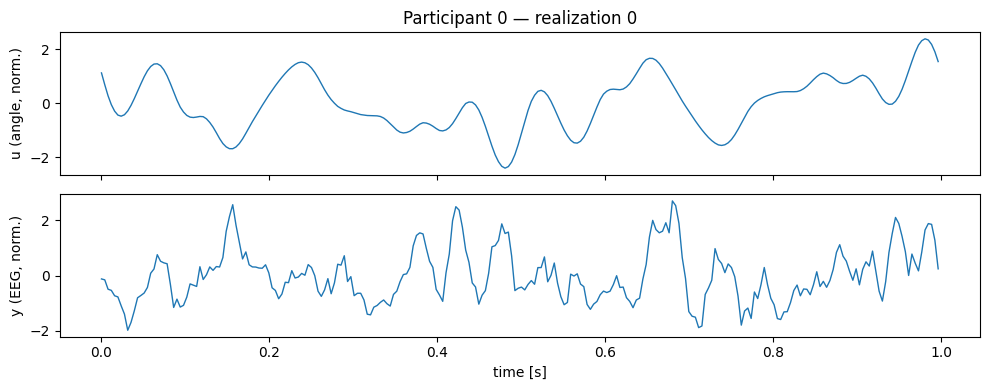

In [60]:
t = np.arange(N) / CFG["fs"]
fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
axes[0].plot(t, u_all[0, 0], lw=1); axes[0].set_ylabel("u (angle, norm.)")
axes[1].plot(t, y_all[0, 0], lw=1); axes[1].set_ylabel("y (EEG, norm.)")
axes[1].set_xlabel("time [s]")
axes[0].set_title("Participant 0 — realization 0")
plt.tight_layout(); plt.show()

## 4. Train / val / test split

Two modes, selected by `CFG["split"]`:

* **`"within"`** — per subject: 5 realizations → train, 1 → val, 1 → test. Model has seen every subject during training.
* **`"loso"`** — subject `loso_test_subject` is fully held out for test. Realizations in `loso_val_real_idx` from the remaining `S-1` subjects go to val; the rest go to train. Model has never seen the test subject.

Both modes produce flat `[num_sequences, N]` arrays so downstream code is unchanged.

In [61]:
def make_split(u_all, y_all, cfg):
    def take(idxs):
        u = u_all[:, idxs, :].reshape(-1, u_all.shape[-1])
        y = y_all[:, idxs, :].reshape(-1, y_all.shape[-1])
        return u, y
    return take(cfg["train_real_idx"]), take(cfg["val_real_idx"]), take(cfg["test_real_idx"])


def make_loso_split(u_all, y_all, cfg):
    S, M, N = u_all.shape
    test_s  = int(cfg["loso_test_subject"])
    val_idx = list(cfg["loso_val_real_idx"])
    tr_idx  = [m for m in range(M) if m not in val_idx]
    # test: every realization of the held-out subject
    u_te = u_all[test_s].reshape(-1, N)
    y_te = y_all[test_s].reshape(-1, N)
    # train + val: all other subjects, split by realization index
    keep  = [s for s in range(S) if s != test_s]
    u_oth = u_all[keep]   # [S-1, M, N]
    y_oth = y_all[keep]
    u_tr = u_oth[:, tr_idx,  :].reshape(-1, N)
    y_tr = y_oth[:, tr_idx,  :].reshape(-1, N)
    u_va = u_oth[:, val_idx, :].reshape(-1, N)
    y_va = y_oth[:, val_idx, :].reshape(-1, N)
    return (u_tr, y_tr), (u_va, y_va), (u_te, y_te)


if CFG["split"] == "within":
    (u_tr, y_tr), (u_va, y_va), (u_te, y_te) = make_split(u_all, y_all, CFG)
    print(f"[within-participant] train: {u_tr.shape}, val: {u_va.shape}, test: {u_te.shape}")
elif CFG["split"] == "loso":
    (u_tr, y_tr), (u_va, y_va), (u_te, y_te) = make_loso_split(u_all, y_all, CFG)
    print(f"[LOSO  test_subject={CFG['loso_test_subject']}] "
          f"train: {u_tr.shape}, val: {u_va.shape}, test: {u_te.shape}")
else:
    raise ValueError(f"unknown split {CFG['split']!r}")

[LOSO  test_subject=0] train: (45, 256), val: (18, 256), test: (7, 256)


## 5. Metrics

Following the nonlinear-benchmarks convention:

* **NRMSE** = RMSE(y, ŷ) / std(y)
* **VAF** = 100 · (1 − var(y − ŷ) / var(y))  (percentage)

In [62]:
def nrmse(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return float(rmse / (y_true.std() + 1e-12))

def vaf(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return float(100.0 * (1.0 - np.var(y_true - y_pred) / (np.var(y_true) + 1e-12)))

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 6. NNARX

Regressor at step k:

`x[k] = [u[k], u[k-1], …, u[k-nu+1], y[k-1], …, y[k-ny]]` (size `nu + ny`)

Trained teacher-forced. At test time we **simulate**: the first `max(nu, ny)` samples of `y` are used as warm-up from the true signal, then predictions are fed back as inputs.

In [63]:
def make_u_feats(u, u_feats=()):
    """u: 1D [T]  ->  [T, F] with channels [u, du, u**2] subset.
       u_feats subset of {'du','usq'}; F = 1 + len(u_feats)."""
    u = np.asarray(u, dtype=np.float32)
    cols = [u]
    if "du" in u_feats:
        du = np.empty_like(u); du[0] = 0.0; du[1:] = u[1:] - u[:-1]
        cols.append(du)
    if "usq" in u_feats:
        cols.append(u * u)
    return np.stack(cols, axis=-1)


def _normalize_taps(u_taps, y_taps, nu, ny):
    """Default consecutive taps when None. u_taps offsets >= 0 (0 = current u);
       y_taps offsets >= 1 (no current y leak)."""
    u_taps = tuple(range(nu)) if u_taps is None else tuple(int(t) for t in u_taps)
    y_taps = tuple(range(1, ny + 1)) if y_taps is None else tuple(int(t) for t in y_taps)
    assert all(t >= 0 for t in u_taps), "u_taps must be non-negative"
    assert all(t >= 1 for t in y_taps), "y_taps must be >= 1"
    return u_taps, y_taps


def build_narx_windows(u_seqs, y_seqs, u_taps, y_taps, residual=False, u_feats=()):
    """1-step teacher-forced regressors with arbitrary lag taps.
       Column order: [u_lags x F-feats] then [y_lags]. Target Delta-y if residual."""
    u_taps_arr = np.asarray(u_taps, dtype=np.int64)
    y_taps_arr = np.asarray(y_taps, dtype=np.int64)
    Lu = int(u_taps_arr.max()) + 1
    Ly = int(y_taps_arr.max()) if len(y_taps_arr) else 0
    L = max(Lu, Ly)
    xs, ts = [], []
    for u, y in zip(u_seqs, y_seqs):
        uf = make_u_feats(u, u_feats)              # [T, F]
        Nseq = len(u)
        for k in range(L, Nseq):
            u_lags = uf[k - u_taps_arr].reshape(-1)   # [nu*F]
            y_lags = y[k - y_taps_arr]                # [ny]
            xs.append(np.concatenate([u_lags, y_lags]))
            ts.append(y[k] - y[k-1] if residual else y[k])
    X = np.stack(xs).astype(np.float32)
    t = np.asarray(ts, dtype=np.float32)[:, None]
    return X, t


def build_narx_rollout(u_seqs, y_seqs, u_taps, y_taps, kstep, u_feats=()):
    """k-step rollout windows with dilated taps.
       U_win [B, Lu+kstep-1, F], Y_warm [B, Ly] (last Ly true y), Y_tgt [B, kstep]."""
    u_taps_arr = np.asarray(u_taps, dtype=np.int64)
    y_taps_arr = np.asarray(y_taps, dtype=np.int64)
    Lu = int(u_taps_arr.max()) + 1
    Ly = int(y_taps_arr.max()) if len(y_taps_arr) else 0
    L = max(Lu, Ly)
    Us, Yw, Yt = [], [], []
    for u, y in zip(u_seqs, y_seqs):
        uf = make_u_feats(u, u_feats)
        Nseq = len(u)
        for k in range(L, Nseq - kstep + 1):
            Us.append(uf[k-Lu+1 : k+kstep])          # [Lu+kstep-1, F]
            Yw.append(y[k-Ly : k] if Ly else np.zeros(0, dtype=np.float32))
            Yt.append(y[k : k+kstep])
    return (np.stack(Us).astype(np.float32),
            np.stack(Yw).astype(np.float32),
            np.stack(Yt).astype(np.float32))


_ACTS = {"tanh": nn.Tanh, "relu": nn.ReLU, "gelu": nn.GELU}


class NNARX(nn.Module):
    def __init__(self, u_taps, y_taps, hidden=(64, 64), act="tanh", residual=False,
                 dropout=0.0, skip=False, u_feats=()):
        super().__init__()
        self.u_taps = tuple(u_taps)
        self.y_taps = tuple(y_taps)
        self.nu = len(self.u_taps)
        self.ny = len(self.y_taps)
        self.Lu = (max(self.u_taps) + 1) if self.u_taps else 0
        self.Ly = max(self.y_taps) if self.y_taps else 0
        self.L  = max(self.Lu, self.Ly)
        self.residual = residual
        self.u_feats = tuple(u_feats)
        self.n_u_feats = 1 + len(self.u_feats)
        in_dim = self.nu * self.n_u_feats + self.ny
        act_cls = _ACTS[act.lower()]
        layers = []
        dims = [in_dim] + list(hidden)
        for a, b in zip(dims[:-1], dims[1:]):
            layers += [nn.Linear(a, b), act_cls()]
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
        layers += [nn.Linear(dims[-1], 1)]
        self.net = nn.Sequential(*layers)
        self.skip = nn.Linear(in_dim, 1) if skip else None
        self.in_dim = in_dim
        # tap tensors (non-persistent buffers) for fast GPU rollout indexing
        self.register_buffer("_u_taps_t",
            torch.as_tensor(self.u_taps, dtype=torch.long), persistent=False)
        self.register_buffer("_y_taps_t",
            torch.as_tensor(self.y_taps, dtype=torch.long), persistent=False)

    def _head(self, x):
        out = self.net(x)
        if self.skip is not None:
            out = out + self.skip(x)
        return out

    def forward(self, x):
        return self._head(x)

    @torch.no_grad()
    def simulate(self, u_seq, y_warmup):
        dev = next(self.parameters()).device
        u = np.asarray(u_seq, dtype=np.float32)
        uf = make_u_feats(u, self.u_feats)
        Nseq = len(u)
        L = self.L
        y_hat = np.zeros(Nseq, dtype=np.float32)
        y_hat[:L] = np.asarray(y_warmup, dtype=np.float32)[:L]
        u_taps_arr = np.asarray(self.u_taps, dtype=np.int64)
        y_taps_arr = np.asarray(self.y_taps, dtype=np.int64)
        self.eval()
        for k in range(L, Nseq):
            u_lags = uf[k - u_taps_arr].reshape(-1)
            y_lags = y_hat[k - y_taps_arr] if self.Ly else np.zeros(0, dtype=np.float32)
            x = np.concatenate([u_lags, y_lags])
            x_t = torch.from_numpy(x).float().unsqueeze(0).to(dev)
            out = float(self._head(x_t).cpu().numpy()[0, 0])
            y_hat[k] = (y_hat[k-1] + out) if (self.residual and self.Ly) else out
        return y_hat

    def rollout(self, U_win, Y_warm, kstep):
        """U_win [B, Lu+kstep-1, F], Y_warm [B, Ly] -> preds [B, kstep] (raw y).
           For step j, u-tap t maps to U_win index (Lu-1+j-t);
           y-tap t maps to y_buf index (Ly - t)."""
        B = U_win.size(0)
        u_taps = self._u_taps_t
        y_taps = self._y_taps_t
        y_buf = Y_warm
        preds = []
        for j in range(kstep):
            idx_u = (self.Lu - 1 + j) - u_taps
            u_slice = U_win.index_select(1, idx_u)        # [B, nu, F]
            u_flat  = u_slice.reshape(B, -1)
            if self.Ly > 0:
                idx_y = self.Ly - y_taps
                y_slice = y_buf.index_select(1, idx_y)    # [B, ny]
                x = torch.cat([u_flat, y_slice], dim=-1)
            else:
                x = u_flat
            out = self._head(x).squeeze(-1)
            y_pred = (y_buf[:, -1] + out) if (self.residual and self.Ly > 0) else out
            preds.append(y_pred)
            if self.Ly > 0:
                y_buf = torch.cat([y_buf[:, 1:], y_pred.unsqueeze(-1)], dim=-1)
        return torch.stack(preds, dim=-1)

## 7. Simple RNN / LSTM / GRU

Closed-loop by construction: input is `u[k]`, hidden state carries the dynamics, linear head outputs `y[k]`.
A forward pass on a test sequence **is** the simulation — no teacher forcing needed at evaluation.

In [64]:
class SeqModel(nn.Module):
    def __init__(self, kind="lstm", hidden=64, layers=1):
        super().__init__()
        cls = {"rnn": nn.RNN, "lstm": nn.LSTM, "gru": nn.GRU}[kind.lower()]
        kwargs = dict(input_size=1, hidden_size=hidden, num_layers=layers, batch_first=True)
        if kind.lower() == "rnn":
            kwargs["nonlinearity"] = "tanh"
        self.rnn = cls(**kwargs)
        self.head = nn.Linear(hidden, 1)
        self.kind = kind; self.hidden = hidden; self.layers = layers

    def forward(self, u):
        h, _ = self.rnn(u)
        return self.head(h)

## 8. Training loops

In [65]:
def train_narx(model, u_tr, y_tr, u_va, y_va, epochs, batch, lr, weight_decay=0.0,
               y_noise_std=0.0, val_every=5, patience_checks=5,
               kstep_schedule=((0, 1),), lr_schedule=None, grad_clip=None,
               spec_lambda=0.0, spec_kstep_min=16,
               curriculum_lr_drop=1.0, curriculum_restore=False, step_decay=1.0):
    """Train NNARX with closed-loop tweaks:
       - 1-step branch: TF + Gaussian noise on past-y regressor.
       - k-step branch: differentiable closed-loop rollout + optional FFT-mag loss
         and geometric step weighting (step_decay**j).
       - Cosine LR schedule (optional). Gradient norm clip (optional).
       - On curriculum advance: optionally restore best weights and multiply LR by
         curriculum_lr_drop (warm restart from a known-good optimum).
       - Periodic simulation-mode val + best-state restore on val sim NRMSE.
       - Patience counter resets when kstep curriculum advances."""
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = (torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
                 if lr_schedule == "cosine" else None)
    loss_fn = nn.MSELoss()

    feats = model.u_feats
    X_tr1, t_tr1 = build_narx_windows(u_tr, y_tr, model.u_taps, model.y_taps,
                                      residual=model.residual, u_feats=feats)
    dl1 = DataLoader(TensorDataset(torch.from_numpy(X_tr1), torch.from_numpy(t_tr1)),
                     batch_size=batch, shuffle=True, drop_last=False)
    y_lo = model.nu * model.n_u_feats
    y_hi = y_lo + model.ny

    rollout_cache = {}
    def get_rollout_loader(k):
        if k in rollout_cache: return rollout_cache[k]
        U, Yw, Yt = build_narx_rollout(u_tr, y_tr, model.u_taps, model.y_taps,
                                       k, u_feats=feats)
        dl = DataLoader(TensorDataset(torch.from_numpy(U), torch.from_numpy(Yw),
                                      torch.from_numpy(Yt)),
                        batch_size=batch, shuffle=True, drop_last=False)
        rollout_cache[k] = dl
        return dl

    sched = sorted(kstep_schedule)
    def current_kstep(ep):
        cur = 1
        for thr, k in sched:
            if ep >= thr: cur = k
        return cur

    history = {"train": [], "val_sim_nrmse": [], "kstep": []}
    best_nrmse, best_state, bad_checks = float("inf"), None, 0
    prev_kstep = None
    t0 = time.time()

    for ep in range(epochs):
        kstep = current_kstep(ep)
        if prev_kstep is not None and kstep != prev_kstep:
            bad_checks = 0  # curriculum advanced -> reset patience
            if curriculum_restore and best_state is not None:
                model.load_state_dict(best_state)
            if curriculum_lr_drop != 1.0:
                for pg in opt.param_groups:
                    pg["lr"] *= curriculum_lr_drop
            print(f"  [curriculum] k {prev_kstep} -> {kstep}: "
                  f"lr={opt.param_groups[0]['lr']:.2e}, "
                  f"restored={curriculum_restore and best_state is not None}")
        prev_kstep = kstep
        history["kstep"].append(kstep)
        model.train(); losses = []
        if kstep <= 1:
            for xb, tb in dl1:
                xb, tb = xb.to(DEVICE), tb.to(DEVICE)
                if y_noise_std > 0.0 and y_hi > y_lo:
                    xb = xb.clone()
                    xb[:, y_lo:y_hi] += torch.randn_like(xb[:, y_lo:y_hi]) * y_noise_std
                opt.zero_grad()
                loss = loss_fn(model(xb), tb); loss.backward()
                if grad_clip is not None:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                opt.step()
                losses.append(loss.item())
        else:
            dl_k = get_rollout_loader(kstep)
            use_spec = (spec_lambda > 0.0 and kstep >= spec_kstep_min)
            use_decay = (step_decay != 1.0)
            if use_decay:
                w = torch.tensor([step_decay ** j for j in range(kstep)],
                                 dtype=torch.float32, device=DEVICE)
                w = w / w.mean()             # keep loss scale comparable to uniform MSE
            for U_b, Yw_b, Yt_b in dl_k:
                U_b  = U_b.to(DEVICE)
                Yw_b = Yw_b.to(DEVICE)
                Yt_b = Yt_b.to(DEVICE)
                if y_noise_std > 0.0 and Yw_b.numel() > 0:
                    Yw_b = Yw_b + torch.randn_like(Yw_b) * y_noise_std
                opt.zero_grad()
                preds = model.rollout(U_b, Yw_b, kstep)
                if use_decay:
                    loss = (((preds - Yt_b) ** 2) * w).mean()
                else:
                    loss = loss_fn(preds, Yt_b)
                if use_spec:
                    P = torch.fft.rfft(preds, dim=-1).abs()
                    T = torch.fft.rfft(Yt_b, dim=-1).abs()
                    loss = loss + spec_lambda * ((P - T) ** 2).mean()
                loss.backward()
                if grad_clip is not None:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                opt.step()
                losses.append(loss.item())

        if scheduler is not None: scheduler.step()
        history["train"].append(float(np.mean(losses)))

        if (ep + 1) % val_every == 0 or ep == epochs - 1:
            y_hat, y_true = eval_narx(model, u_va, y_va)
            v_nrmse = nrmse(y_true, y_hat)
            history["val_sim_nrmse"].append((ep + 1, v_nrmse))
            improved = v_nrmse < best_nrmse - 1e-4
            if improved:
                best_nrmse = v_nrmse
                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
                bad_checks = 0; tag = "(best)"
            else:
                bad_checks += 1; tag = f"(no improve {bad_checks}/{patience_checks})"
            lr_now = opt.param_groups[0]["lr"]
            print(f"ep {ep+1:3d}/{epochs}  k={kstep}  lr={lr_now:.2e}  "
                  f"train {history['train'][-1]:.4e}  val sim NRMSE {v_nrmse:.4f}  {tag}")
            if bad_checks >= patience_checks:
                print(f"early stop at epoch {ep+1} (best val sim NRMSE = {best_nrmse:.4f})")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return history, time.time() - t0


def train_seq(model, u_tr, y_tr, u_va, y_va, epochs, lr, weight_decay=0.0,
              val_every=5, patience=20):
    """Train recurrent model with cosine LR, sim-based val, early stopping."""
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn = nn.MSELoss()
    U_tr = torch.from_numpy(u_tr).float().unsqueeze(-1).to(DEVICE)
    Y_tr = torch.from_numpy(y_tr).float().unsqueeze(-1).to(DEVICE)
    history = {"train": [], "val_nrmse": []}
    best_nrmse, best_state, bad = float("inf"), None, 0
    t0 = time.time()
    for ep in range(epochs):
        model.train(); opt.zero_grad()
        loss = loss_fn(model(U_tr), Y_tr); loss.backward(); opt.step()
        scheduler.step()
        history["train"].append(loss.item())

        if (ep + 1) % val_every == 0 or ep == epochs - 1:
            y_hat, y_true = eval_seq(model, u_va, y_va)
            v_nrmse = nrmse(y_true, y_hat)
            history["val_nrmse"].append((ep + 1, v_nrmse))
            improved = v_nrmse < best_nrmse - 1e-4
            if improved:
                best_nrmse = v_nrmse
                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
                bad = 0; tag = "(best)"
            else:
                bad += 1; tag = f"(no improve {bad}/{patience})"
            lr_now = opt.param_groups[0]["lr"]
            print(f"ep {ep+1:3d}/{epochs}  lr={lr_now:.2e}  train {history['train'][-1]:.4e}"
                  f"  val sim NRMSE {v_nrmse:.4f}  {tag}")
            if bad >= patience:
                print(f"early stop at epoch {ep+1} (best val sim NRMSE = {best_nrmse:.4f})")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return history, time.time() - t0

## 9. Simulation-mode evaluation

In [66]:
def eval_narx(model, u_seqs, y_seqs):
    preds, truths = [], []
    for u, y in zip(u_seqs, y_seqs):
        L = model.L                      # warmup = max lag span (Lu, Ly), not tap count
        preds.append(model.simulate(u, y[:L]))
        truths.append(np.asarray(y, dtype=np.float32))
    return np.concatenate(preds), np.concatenate(truths)

def eval_seq(model, u_seqs, y_seqs):
    model.eval()
    U = torch.from_numpy(u_seqs).float().unsqueeze(-1).to(DEVICE)
    with torch.no_grad():
        pred = model(U).squeeze(-1).cpu().numpy()
    return pred.reshape(-1), np.asarray(y_seqs, dtype=np.float32).reshape(-1)

## 10. Parameters and FLOPs per output sample

Analytic counts (one multiply-add = 2 FLOPs). Recurrent cells aren't handled well by `ptflops`, so we compute them in closed form.

In [67]:
def flops_per_sample(model):
    if isinstance(model, NNARX):
        in_dim = model.nu * model.n_u_feats + model.ny
        f, prev = 0, in_dim
        for layer in model.net:
            if isinstance(layer, nn.Linear):
                f += 2 * prev * layer.out_features + layer.out_features
                prev = layer.out_features
        if model.skip is not None:
            f += 2 * in_dim * 1 + 1
        return f
    if isinstance(model, SeqModel):
        H, L, kind = model.hidden, model.layers, model.kind.lower()
        gates = {"rnn": 1, "gru": 3, "lstm": 4}[kind]
        # per step, layer 1: gates*(input->hidden + hidden->hidden) + biases + nonlinearities
        f_layer1 = 2 * gates * (1 * H + H * H) + gates * H
        f_other  = 2 * gates * (H * H + H * H) + gates * H
        total = f_layer1 + (L - 1) * f_other
        # per-step elementwise ops for gated cells (tanh/sigmoid/hadamard)
        if kind == "lstm": total += 5 * H
        elif kind == "gru": total += 3 * H
        total += 2 * H * 1 + 1                 # linear head
        return total
    return None

## 11. Phase 1 — run one model end-to-end

`run_nnarx` / `run_seq` wrap training, simulation-mode evaluation on the test realization, param and FLOPs counts, and a simulated-vs-true plot.

In [68]:
def plot_sim(y_true, y_pred, title, n=None):
    if n is None:
        n = min(len(y_true), 4 * int(CFG["fs"]))
    t = np.arange(n) / CFG["fs"]
    plt.figure(figsize=(10, 3))
    plt.plot(t, y_true[:n], label="true", lw=1)
    plt.plot(t, y_pred[:n], label="sim",  lw=1, alpha=0.8)
    plt.xlabel("time [s]"); plt.ylabel("y"); plt.title(title)
    plt.legend(); plt.tight_layout(); plt.show()


RESULTS = {}


def _make_nnarx(cfg):
    u_taps, y_taps = _normalize_taps(cfg.get("narx_u_taps"),
                                     cfg.get("narx_y_taps"),
                                     cfg["narx_nu"], cfg["narx_ny"])
    return NNARX(u_taps, y_taps,
                 hidden=tuple(cfg["narx_hidden"]),
                 act=cfg.get("narx_act", "tanh"),
                 residual=cfg.get("narx_residual", False),
                 dropout=cfg.get("narx_dropout", 0.0),
                 skip=cfg.get("narx_skip", False),
                 u_feats=tuple(cfg.get("narx_u_feats", ())))


def _train_one_nnarx(cfg, seed_offset):
    torch.manual_seed(SEED + seed_offset); np.random.seed(SEED + seed_offset)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED + seed_offset)
    model = _make_nnarx(cfg)
    history, elapsed = train_narx(
        model, u_tr, y_tr, u_va, y_va,
        epochs=cfg["epochs_narx"], batch=cfg["batch_narx"],
        lr=cfg["lr"],
        weight_decay=cfg.get("narx_weight_decay", cfg.get("weight_decay", 0.0)),
        y_noise_std=cfg.get("narx_y_noise_std", 0.0),
        val_every=cfg.get("narx_val_every", 5),
        patience_checks=cfg.get("narx_patience_checks", 5),
        kstep_schedule=cfg.get("narx_kstep_schedule", ((0, 1),)),
        lr_schedule=cfg.get("narx_lr_schedule", None),
        grad_clip=cfg.get("narx_grad_clip", None),
        spec_lambda=cfg.get("narx_spec_lambda", 0.0),
        spec_kstep_min=cfg.get("narx_spec_kstep_min", 16),
        curriculum_lr_drop=cfg.get("narx_curriculum_lr_drop", 1.0),
        curriculum_restore=cfg.get("narx_curriculum_restore", False),
        step_decay=cfg.get("narx_step_decay", 1.0),
    )
    return model, history, elapsed


def run_nnarx(cfg, tag="nnarx"):
    n_ens = int(cfg.get("narx_ensemble", 1))
    sim_per_model = []
    total_t = 0.0
    last_model, last_history = None, None
    for i in range(n_ens):
        if n_ens > 1:
            print(f"\n[ensemble member {i+1}/{n_ens}]")
        model, history, elapsed = _train_one_nnarx(cfg, seed_offset=i)
        if i == 0:
            print(f"NNARX params: {count_params(model):,}  "
                  f"residual={model.residual}  skip={model.skip is not None}  "
                  f"act={cfg.get('narx_act','tanh')}  "
                  f"u_feats={model.u_feats}  ensemble={n_ens}")
            print(f"  u_taps={model.u_taps}  y_taps={model.y_taps}  "
                  f"L_warm={model.L} (Lu={model.Lu}, Ly={model.Ly})")
        seq_preds = []
        for u_seq, y_seq in zip(u_te, y_te):
            L = model.L
            seq_preds.append(model.simulate(u_seq, y_seq[:L]))
        sim_per_model.append(np.concatenate(seq_preds))
        total_t += elapsed
        last_model, last_history = model, history

    y_hat = np.mean(np.stack(sim_per_model, axis=0), axis=0)
    y_true = np.concatenate([np.asarray(y, dtype=np.float32) for y in y_te])
    res = dict(model="NNARX", params=count_params(last_model),
               flops_per_sample=flops_per_sample(last_model) * n_ens,
               train_time_s=total_t, ensemble=n_ens,
               nrmse_sim=nrmse(y_true, y_hat), vaf_sim=vaf(y_true, y_hat),
               history=last_history)
    print(f"test sim NRMSE={res['nrmse_sim']:.4f}, VAF={res['vaf_sim']:.2f}%, "
          f"train_time={total_t:.1f}s, FLOPs/sample={res['flops_per_sample']:,}")
    plot_sim(y_true, y_hat, title="NNARX -- simulation on test (first seconds)")
    return last_model, res


def run_seq(kind, cfg):
    model = SeqModel(kind=kind, hidden=cfg["rec_hidden"], layers=cfg["rec_layers"])
    print(f"{kind.upper()} params: {count_params(model):,}")
    history, elapsed = train_seq(model, u_tr, y_tr, u_va, y_va,
                                 epochs=cfg["epochs_rec"],
                                 lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    y_hat, y_true = eval_seq(model, u_te, y_te)
    res = dict(model=kind.upper(), params=count_params(model),
               flops_per_sample=flops_per_sample(model),
               train_time_s=elapsed,
               nrmse_sim=nrmse(y_true, y_hat), vaf_sim=vaf(y_true, y_hat),
               history=history)
    print(f"test sim NRMSE={res['nrmse_sim']:.4f}, VAF={res['vaf_sim']:.2f}%, "
          f"train_time={elapsed:.1f}s, FLOPs/sample={res['flops_per_sample']:,}")
    plot_sim(y_true, y_hat, title=f"{kind.upper()} -- simulation on test (first seconds)")
    return model, res

### NNARX


[ensemble member 1/3]
ep   2/200  k=1  lr=1.00e-03  train 2.7673e-01  val sim NRMSE 0.8803  (best)
ep   4/200  k=1  lr=9.99e-04  train 2.1582e-01  val sim NRMSE 0.8591  (best)
ep   6/200  k=1  lr=9.98e-04  train 2.0191e-01  val sim NRMSE 0.8646  (no improve 1/8)
ep   8/200  k=1  lr=9.96e-04  train 1.9468e-01  val sim NRMSE 0.8753  (no improve 2/8)
ep  10/200  k=1  lr=9.94e-04  train 1.9222e-01  val sim NRMSE 0.8684  (no improve 3/8)
ep  12/200  k=1  lr=9.91e-04  train 1.8962e-01  val sim NRMSE 0.8699  (no improve 4/8)
ep  14/200  k=1  lr=9.88e-04  train 1.8717e-01  val sim NRMSE 0.8658  (no improve 5/8)
  [curriculum] k 1 -> 5: lr=4.93e-04, restored=True
ep  16/200  k=5  lr=4.92e-04  train 6.5258e-01  val sim NRMSE 0.8697  (no improve 1/8)
ep  18/200  k=5  lr=4.90e-04  train 6.3275e-01  val sim NRMSE 0.8601  (no improve 2/8)
ep  20/200  k=5  lr=4.88e-04  train 6.2242e-01  val sim NRMSE 0.8619  (no improve 3/8)
ep  22/200  k=5  lr=4.85e-04  train 6.1326e-01  val sim NRMSE 0.8536  (best

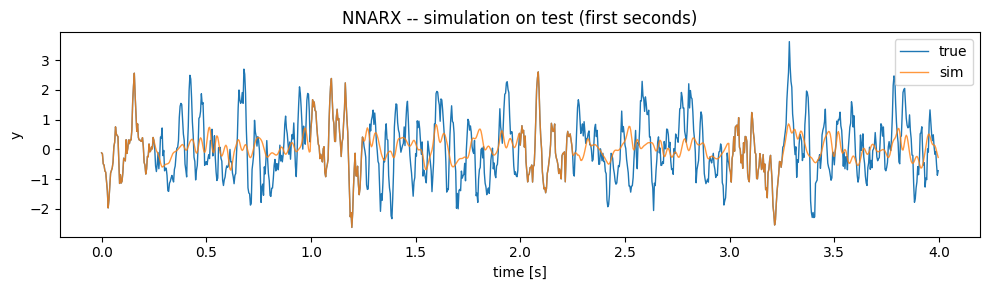

In [69]:
model_nnarx, RESULTS["nnarx"] = run_nnarx(CFG)

### Simple RNN

RNN params: 4,353
ep   5/200  lr=9.98e-04  train 1.0480e+00  val sim NRMSE 1.0002  (best)
ep  10/200  lr=9.94e-04  train 1.0481e+00  val sim NRMSE 1.0000  (best)
ep  15/200  lr=9.86e-04  train 1.0469e+00  val sim NRMSE 0.9995  (best)
ep  20/200  lr=9.76e-04  train 1.0457e+00  val sim NRMSE 0.9995  (no improve 1/20)
ep  25/200  lr=9.62e-04  train 1.0458e+00  val sim NRMSE 0.9998  (no improve 2/20)
ep  30/200  lr=9.46e-04  train 1.0456e+00  val sim NRMSE 0.9997  (no improve 3/20)
ep  35/200  lr=9.26e-04  train 1.0453e+00  val sim NRMSE 0.9995  (no improve 4/20)
ep  40/200  lr=9.05e-04  train 1.0452e+00  val sim NRMSE 0.9993  (best)
ep  45/200  lr=8.80e-04  train 1.0450e+00  val sim NRMSE 0.9993  (no improve 1/20)
ep  50/200  lr=8.54e-04  train 1.0449e+00  val sim NRMSE 0.9994  (no improve 2/20)
ep  55/200  lr=8.25e-04  train 1.0447e+00  val sim NRMSE 0.9995  (no improve 3/20)
ep  60/200  lr=7.94e-04  train 1.0445e+00  val sim NRMSE 0.9994  (no improve 4/20)
ep  65/200  lr=7.61e-04  train

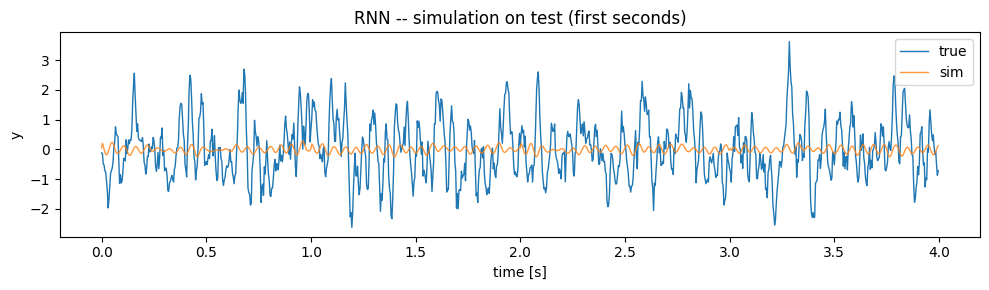

In [70]:
model_rnn, RESULTS["rnn"] = run_seq("rnn", CFG)

### LSTM

LSTM params: 17,217
ep   5/200  lr=9.98e-04  train 1.0469e+00  val sim NRMSE 1.0001  (best)
ep  10/200  lr=9.94e-04  train 1.0463e+00  val sim NRMSE 0.9995  (best)
ep  15/200  lr=9.86e-04  train 1.0463e+00  val sim NRMSE 0.9993  (best)
ep  20/200  lr=9.76e-04  train 1.0461e+00  val sim NRMSE 0.9991  (best)
ep  25/200  lr=9.62e-04  train 1.0459e+00  val sim NRMSE 0.9991  (no improve 1/20)
ep  30/200  lr=9.46e-04  train 1.0458e+00  val sim NRMSE 0.9990  (best)
ep  35/200  lr=9.26e-04  train 1.0457e+00  val sim NRMSE 0.9989  (best)
ep  40/200  lr=9.05e-04  train 1.0455e+00  val sim NRMSE 0.9986  (best)
ep  45/200  lr=8.80e-04  train 1.0454e+00  val sim NRMSE 0.9983  (best)
ep  50/200  lr=8.54e-04  train 1.0452e+00  val sim NRMSE 0.9978  (best)
ep  55/200  lr=8.25e-04  train 1.0449e+00  val sim NRMSE 0.9972  (best)
ep  60/200  lr=7.94e-04  train 1.0446e+00  val sim NRMSE 0.9962  (best)
ep  65/200  lr=7.61e-04  train 1.0440e+00  val sim NRMSE 0.9946  (best)
ep  70/200  lr=7.27e-04  train 1.

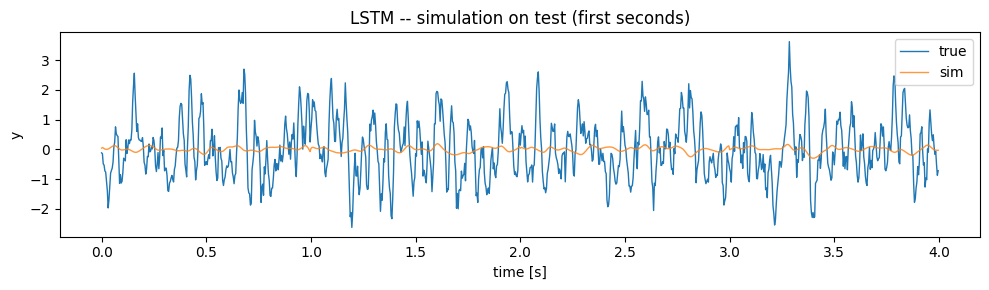

In [71]:
model_lstm, RESULTS["lstm"] = run_seq("lstm", CFG)

### GRU (optional in the brief)

GRU params: 12,929
ep   5/200  lr=9.98e-04  train 1.0501e+00  val sim NRMSE 1.0006  (best)
ep  10/200  lr=9.94e-04  train 1.0460e+00  val sim NRMSE 0.9999  (best)
ep  15/200  lr=9.86e-04  train 1.0475e+00  val sim NRMSE 1.0005  (no improve 1/20)
ep  20/200  lr=9.76e-04  train 1.0459e+00  val sim NRMSE 0.9995  (best)
ep  25/200  lr=9.62e-04  train 1.0451e+00  val sim NRMSE 0.9991  (best)
ep  30/200  lr=9.46e-04  train 1.0453e+00  val sim NRMSE 0.9992  (no improve 1/20)
ep  35/200  lr=9.26e-04  train 1.0451e+00  val sim NRMSE 0.9990  (no improve 2/20)
ep  40/200  lr=9.05e-04  train 1.0447e+00  val sim NRMSE 0.9988  (best)
ep  45/200  lr=8.80e-04  train 1.0446e+00  val sim NRMSE 0.9987  (best)
ep  50/200  lr=8.54e-04  train 1.0445e+00  val sim NRMSE 0.9986  (best)
ep  55/200  lr=8.25e-04  train 1.0443e+00  val sim NRMSE 0.9984  (best)
ep  60/200  lr=7.94e-04  train 1.0441e+00  val sim NRMSE 0.9983  (best)
ep  65/200  lr=7.61e-04  train 1.0439e+00  val sim NRMSE 0.9980  (best)
ep  70/200  

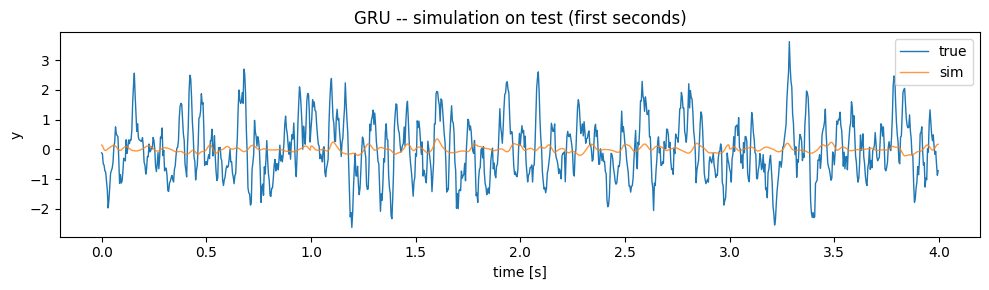

In [72]:
model_gru, RESULTS["gru"] = run_seq("gru", CFG)

## 12. Phase 2 — Architecture sweep

Small LSTM grid as an example (hidden width × number of layers). Extend to NNARX widths / RNN / GRU once you're happy with the pipeline.


--- LSTM hidden=32 layers=1 ---
LSTM params: 4,513
ep   5/100  lr=9.94e-04  train 1.0657e+00  val sim NRMSE 1.0088  (best)
ep  10/100  lr=9.76e-04  train 1.0548e+00  val sim NRMSE 1.0036  (best)
ep  15/100  lr=9.46e-04  train 1.0489e+00  val sim NRMSE 1.0011  (best)
ep  20/100  lr=9.05e-04  train 1.0470e+00  val sim NRMSE 1.0005  (best)
ep  25/100  lr=8.54e-04  train 1.0471e+00  val sim NRMSE 1.0007  (no improve 1/20)
ep  30/100  lr=7.94e-04  train 1.0472e+00  val sim NRMSE 1.0007  (no improve 2/20)
ep  35/100  lr=7.27e-04  train 1.0470e+00  val sim NRMSE 1.0005  (no improve 3/20)
ep  40/100  lr=6.55e-04  train 1.0466e+00  val sim NRMSE 1.0003  (best)
ep  45/100  lr=5.78e-04  train 1.0464e+00  val sim NRMSE 1.0001  (best)
ep  50/100  lr=5.00e-04  train 1.0464e+00  val sim NRMSE 1.0000  (best)
ep  55/100  lr=4.22e-04  train 1.0463e+00  val sim NRMSE 0.9999  (no improve 1/20)
ep  60/100  lr=3.45e-04  train 1.0463e+00  val sim NRMSE 0.9998  (best)
ep  65/100  lr=2.73e-04  train 1.0463e+0

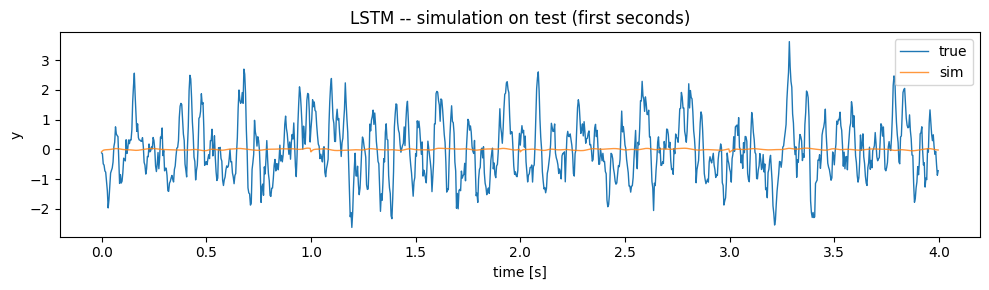


--- LSTM hidden=32 layers=2 ---
LSTM params: 12,961
ep   5/100  lr=9.94e-04  train 1.0462e+00  val sim NRMSE 0.9995  (best)
ep  10/100  lr=9.76e-04  train 1.0460e+00  val sim NRMSE 0.9993  (best)
ep  15/100  lr=9.46e-04  train 1.0460e+00  val sim NRMSE 0.9990  (best)
ep  20/100  lr=9.05e-04  train 1.0459e+00  val sim NRMSE 0.9989  (best)
ep  25/100  lr=8.54e-04  train 1.0458e+00  val sim NRMSE 0.9988  (best)
ep  30/100  lr=7.94e-04  train 1.0457e+00  val sim NRMSE 0.9985  (best)
ep  35/100  lr=7.27e-04  train 1.0456e+00  val sim NRMSE 0.9980  (best)
ep  40/100  lr=6.55e-04  train 1.0453e+00  val sim NRMSE 0.9973  (best)
ep  45/100  lr=5.78e-04  train 1.0449e+00  val sim NRMSE 0.9962  (best)
ep  50/100  lr=5.00e-04  train 1.0442e+00  val sim NRMSE 0.9948  (best)
ep  55/100  lr=4.22e-04  train 1.0431e+00  val sim NRMSE 0.9933  (best)
ep  60/100  lr=3.45e-04  train 1.0411e+00  val sim NRMSE 0.9922  (best)
ep  65/100  lr=2.73e-04  train 1.0385e+00  val sim NRMSE 0.9923  (no improve 1/20)


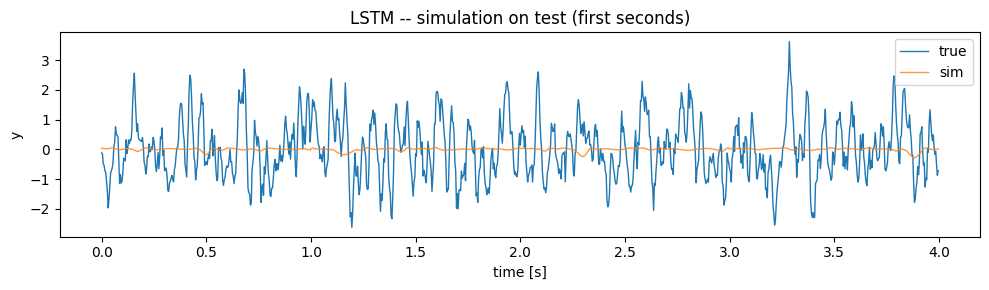


--- LSTM hidden=64 layers=1 ---
LSTM params: 17,217
ep   5/100  lr=9.94e-04  train 1.0459e+00  val sim NRMSE 0.9998  (best)
ep  10/100  lr=9.76e-04  train 1.0455e+00  val sim NRMSE 0.9992  (best)
ep  15/100  lr=9.46e-04  train 1.0454e+00  val sim NRMSE 0.9987  (best)
ep  20/100  lr=9.05e-04  train 1.0450e+00  val sim NRMSE 0.9979  (best)
ep  25/100  lr=8.54e-04  train 1.0447e+00  val sim NRMSE 0.9969  (best)
ep  30/100  lr=7.94e-04  train 1.0442e+00  val sim NRMSE 0.9956  (best)
ep  35/100  lr=7.27e-04  train 1.0434e+00  val sim NRMSE 0.9937  (best)
ep  40/100  lr=6.55e-04  train 1.0417e+00  val sim NRMSE 0.9922  (best)
ep  45/100  lr=5.78e-04  train 1.0387e+00  val sim NRMSE 0.9928  (no improve 1/20)
ep  50/100  lr=5.00e-04  train 1.0356e+00  val sim NRMSE 0.9944  (no improve 2/20)
ep  55/100  lr=4.22e-04  train 1.0324e+00  val sim NRMSE 0.9943  (no improve 3/20)
ep  60/100  lr=3.45e-04  train 1.0297e+00  val sim NRMSE 0.9944  (no improve 4/20)
ep  65/100  lr=2.73e-04  train 1.0276e+

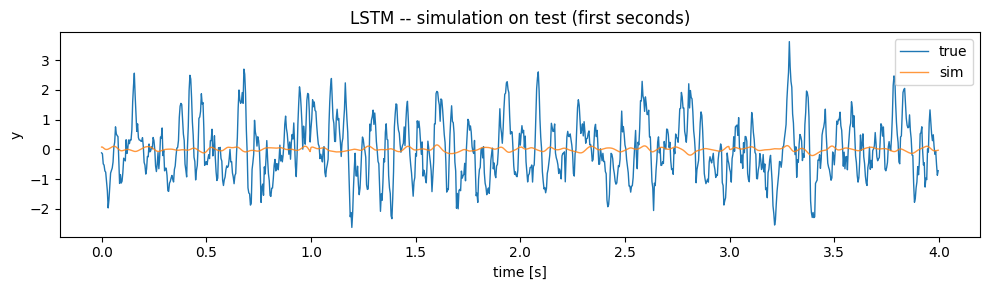


--- LSTM hidden=64 layers=2 ---
LSTM params: 50,497
ep   5/100  lr=9.94e-04  train 1.0464e+00  val sim NRMSE 1.0001  (best)
ep  10/100  lr=9.76e-04  train 1.0473e+00  val sim NRMSE 1.0001  (no improve 1/20)
ep  15/100  lr=9.46e-04  train 1.0460e+00  val sim NRMSE 0.9993  (best)
ep  20/100  lr=9.05e-04  train 1.0461e+00  val sim NRMSE 0.9992  (no improve 1/20)
ep  25/100  lr=8.54e-04  train 1.0461e+00  val sim NRMSE 0.9991  (best)
ep  30/100  lr=7.94e-04  train 1.0458e+00  val sim NRMSE 0.9989  (best)
ep  35/100  lr=7.27e-04  train 1.0458e+00  val sim NRMSE 0.9988  (no improve 1/20)
ep  40/100  lr=6.55e-04  train 1.0457e+00  val sim NRMSE 0.9987  (best)
ep  45/100  lr=5.78e-04  train 1.0455e+00  val sim NRMSE 0.9984  (best)
ep  50/100  lr=5.00e-04  train 1.0452e+00  val sim NRMSE 0.9978  (best)
ep  55/100  lr=4.22e-04  train 1.0445e+00  val sim NRMSE 0.9967  (best)
ep  60/100  lr=3.45e-04  train 1.0424e+00  val sim NRMSE 0.9956  (best)
ep  65/100  lr=2.73e-04  train 1.0394e+00  val sim

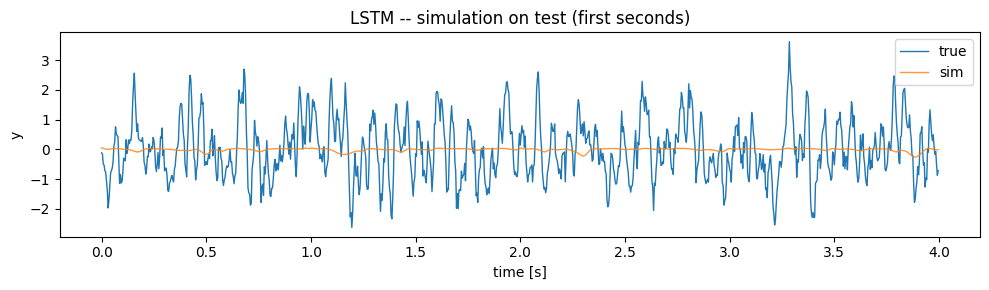


--- LSTM hidden=128 layers=1 ---
LSTM params: 67,201
ep   5/100  lr=9.94e-04  train 1.0460e+00  val sim NRMSE 0.9992  (best)
ep  10/100  lr=9.76e-04  train 1.0456e+00  val sim NRMSE 0.9990  (best)
ep  15/100  lr=9.46e-04  train 1.0452e+00  val sim NRMSE 0.9982  (best)
ep  20/100  lr=9.05e-04  train 1.0448e+00  val sim NRMSE 0.9969  (best)
ep  25/100  lr=8.54e-04  train 1.0439e+00  val sim NRMSE 0.9942  (best)
ep  30/100  lr=7.94e-04  train 1.0396e+00  val sim NRMSE 0.9930  (best)
ep  35/100  lr=7.27e-04  train 1.0364e+00  val sim NRMSE 0.9958  (no improve 1/20)
ep  40/100  lr=6.55e-04  train 1.0320e+00  val sim NRMSE 0.9935  (no improve 2/20)
ep  45/100  lr=5.78e-04  train 1.0291e+00  val sim NRMSE 0.9961  (no improve 3/20)
ep  50/100  lr=5.00e-04  train 1.0266e+00  val sim NRMSE 1.0007  (no improve 4/20)
ep  55/100  lr=4.22e-04  train 1.0247e+00  val sim NRMSE 1.0052  (no improve 5/20)
ep  60/100  lr=3.45e-04  train 1.0235e+00  val sim NRMSE 1.0053  (no improve 6/20)
ep  65/100  lr=2

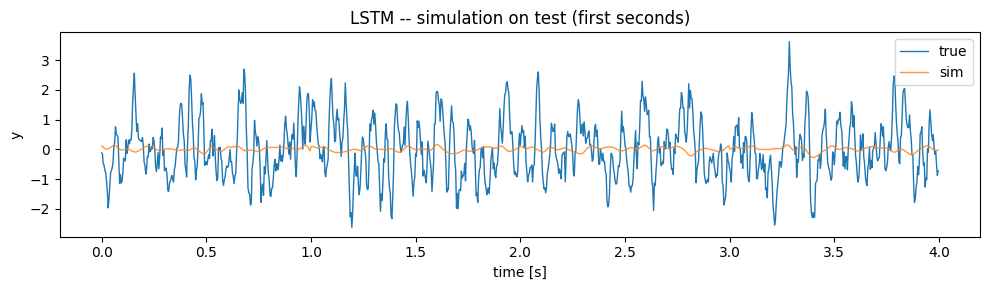


--- LSTM hidden=128 layers=2 ---
LSTM params: 199,297
ep   5/100  lr=9.94e-04  train 1.0464e+00  val sim NRMSE 0.9996  (best)
ep  10/100  lr=9.76e-04  train 1.0461e+00  val sim NRMSE 0.9993  (best)
ep  15/100  lr=9.46e-04  train 1.0458e+00  val sim NRMSE 0.9991  (best)
ep  20/100  lr=9.05e-04  train 1.0455e+00  val sim NRMSE 0.9983  (best)
ep  25/100  lr=8.54e-04  train 1.0448e+00  val sim NRMSE 0.9959  (best)
ep  30/100  lr=7.94e-04  train 1.0410e+00  val sim NRMSE 0.9888  (best)
ep  35/100  lr=7.27e-04  train 1.0326e+00  val sim NRMSE 0.9969  (no improve 1/20)
ep  40/100  lr=6.55e-04  train 1.0301e+00  val sim NRMSE 0.9962  (no improve 2/20)
ep  45/100  lr=5.78e-04  train 1.0275e+00  val sim NRMSE 0.9977  (no improve 3/20)
ep  50/100  lr=5.00e-04  train 1.0255e+00  val sim NRMSE 1.0024  (no improve 4/20)
ep  55/100  lr=4.22e-04  train 1.0231e+00  val sim NRMSE 1.0057  (no improve 5/20)
ep  60/100  lr=3.45e-04  train 1.0206e+00  val sim NRMSE 1.0062  (no improve 6/20)
ep  65/100  lr=

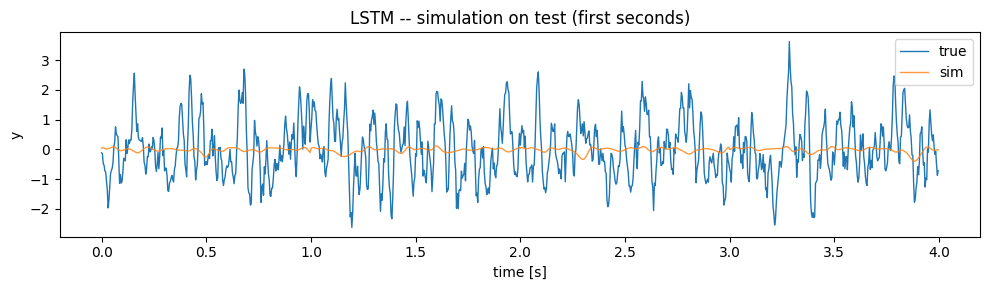


Phase 2 summary (sorted by sim NRMSE):
LSTM h=128 L=1  NRMSE=0.995  VAF=1.1%  params=67,201  flops=133,505  t=0.5s
LSTM h= 64 L=2  NRMSE=0.997  VAF=0.5%  params=50,497  flops=99,777  t=0.3s
LSTM h= 64 L=1  NRMSE=0.998  VAF=0.4%  params=17,217  flops=33,985  t=0.2s
LSTM h= 32 L=1  NRMSE=0.998  VAF=0.4%  params=4,513  flops=8,801  t=0.2s
LSTM h=128 L=2  NRMSE=1.000  VAF=0.0%  params=199,297  flops=396,161  t=1.1s
LSTM h= 32 L=2  NRMSE=1.002  VAF=-0.3%  params=12,961  flops=25,313  t=0.3s


In [73]:
PHASE2 = []
for hidden in (32, 64, 128):
    for layers in (1, 2):
        cfg = dict(CFG); cfg["rec_hidden"] = hidden; cfg["rec_layers"] = layers
        cfg["epochs_rec"] = 100
        print(f"\n--- LSTM hidden={hidden} layers={layers} ---")
        _, res = run_seq("lstm", cfg)
        res["hidden"] = hidden; res["layers"] = layers
        PHASE2.append(res)

print("\nPhase 2 summary (sorted by sim NRMSE):")
for r in sorted(PHASE2, key=lambda r: r["nrmse_sim"]):
    print(f"LSTM h={r['hidden']:3d} L={r['layers']}  "
          f"NRMSE={r['nrmse_sim']:.3f}  VAF={r['vaf_sim']:.1f}%  "
          f"params={r['params']:,}  flops={r['flops_per_sample']:,}  "
          f"t={r['train_time_s']:.1f}s")

### Phase 2 — NNARX `(nu, ny)` sweep

Memory of past inputs/outputs sets the regressor capacity. fs=256 Hz on the medium dataset means 10 samples ≈ 39 ms — very short relative to typical EEG dynamics. Sweep a few orders to find the elbow.


--- NNARX consec  nu=ny=10 ---
ep   2/100  k=1  lr=9.99e-04  train 2.2793e-01  val sim NRMSE 0.9911  (best)
ep   4/100  k=1  lr=9.96e-04  train 1.9807e-01  val sim NRMSE 0.9814  (best)
ep   6/100  k=1  lr=9.91e-04  train 1.8962e-01  val sim NRMSE 0.9870  (no improve 1/8)
ep   8/100  k=1  lr=9.84e-04  train 1.8642e-01  val sim NRMSE 0.9646  (best)
ep  10/100  k=1  lr=9.76e-04  train 1.8533e-01  val sim NRMSE 0.9585  (best)
ep  12/100  k=1  lr=9.65e-04  train 1.8411e-01  val sim NRMSE 0.9659  (no improve 1/8)
ep  14/100  k=1  lr=9.52e-04  train 1.8301e-01  val sim NRMSE 0.9732  (no improve 2/8)
  [curriculum] k 1 -> 5: lr=4.73e-04, restored=True
ep  16/100  k=5  lr=4.69e-04  train 6.1839e-01  val sim NRMSE 0.9631  (no improve 1/8)
ep  18/100  k=5  lr=4.61e-04  train 6.1813e-01  val sim NRMSE 0.9667  (no improve 2/8)
ep  20/100  k=5  lr=4.52e-04  train 6.1157e-01  val sim NRMSE 0.9630  (no improve 3/8)
ep  22/100  k=5  lr=4.43e-04  train 5.9969e-01  val sim NRMSE 0.9717  (no improve 4/8)

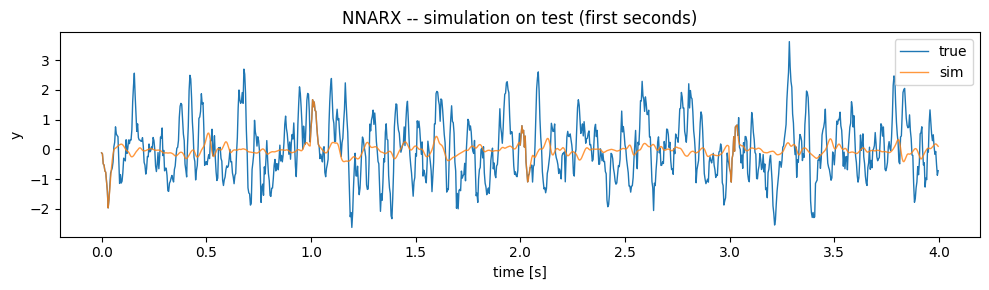


--- NNARX consec  nu=ny=20 ---
ep   2/100  k=1  lr=9.99e-04  train 2.1012e-01  val sim NRMSE 0.9783  (best)
ep   4/100  k=1  lr=9.96e-04  train 1.9197e-01  val sim NRMSE 0.9559  (best)
ep   6/100  k=1  lr=9.91e-04  train 1.8437e-01  val sim NRMSE 0.9414  (best)
ep   8/100  k=1  lr=9.84e-04  train 1.8103e-01  val sim NRMSE 0.9327  (best)
ep  10/100  k=1  lr=9.76e-04  train 1.8027e-01  val sim NRMSE 0.9224  (best)
ep  12/100  k=1  lr=9.65e-04  train 1.7960e-01  val sim NRMSE 0.9133  (best)
ep  14/100  k=1  lr=9.52e-04  train 1.7870e-01  val sim NRMSE 0.9147  (no improve 1/8)
  [curriculum] k 1 -> 5: lr=4.73e-04, restored=True
ep  16/100  k=5  lr=4.69e-04  train 5.6621e-01  val sim NRMSE 0.9194  (no improve 1/8)
ep  18/100  k=5  lr=4.61e-04  train 5.5745e-01  val sim NRMSE 0.9111  (best)
ep  20/100  k=5  lr=4.52e-04  train 5.5298e-01  val sim NRMSE 0.9035  (best)
ep  22/100  k=5  lr=4.43e-04  train 5.4652e-01  val sim NRMSE 0.9067  (no improve 1/8)
ep  24/100  k=5  lr=4.32e-04  train 5.4

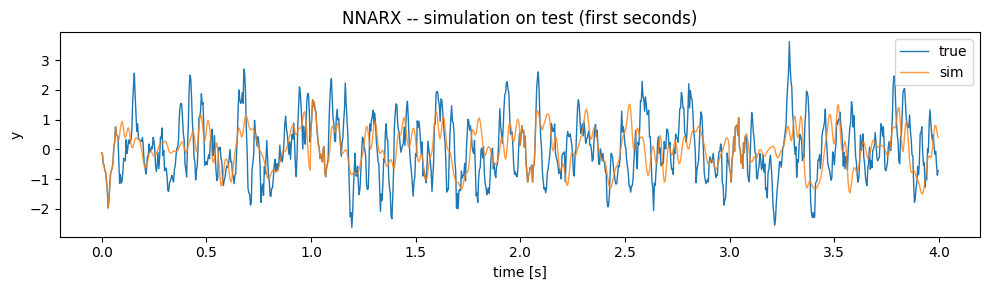


--- NNARX dilated short ---
ep   2/100  k=1  lr=9.99e-04  train 2.1627e-01  val sim NRMSE 0.9630  (best)
ep   4/100  k=1  lr=9.96e-04  train 1.9186e-01  val sim NRMSE 0.9737  (no improve 1/8)
ep   6/100  k=1  lr=9.91e-04  train 1.8842e-01  val sim NRMSE 0.9782  (no improve 2/8)
ep   8/100  k=1  lr=9.84e-04  train 1.8656e-01  val sim NRMSE 0.9680  (no improve 3/8)
ep  10/100  k=1  lr=9.76e-04  train 1.8506e-01  val sim NRMSE 0.9642  (no improve 4/8)
ep  12/100  k=1  lr=9.65e-04  train 1.7988e-01  val sim NRMSE 0.9693  (no improve 5/8)
ep  14/100  k=1  lr=9.52e-04  train 1.8052e-01  val sim NRMSE 0.9609  (best)
  [curriculum] k 1 -> 5: lr=4.73e-04, restored=True
ep  16/100  k=5  lr=4.69e-04  train 6.0949e-01  val sim NRMSE 0.9550  (best)
ep  18/100  k=5  lr=4.61e-04  train 6.0161e-01  val sim NRMSE 0.9660  (no improve 1/8)
ep  20/100  k=5  lr=4.52e-04  train 6.0001e-01  val sim NRMSE 0.9614  (no improve 2/8)
ep  22/100  k=5  lr=4.43e-04  train 5.9262e-01  val sim NRMSE 0.9501  (best)
ep

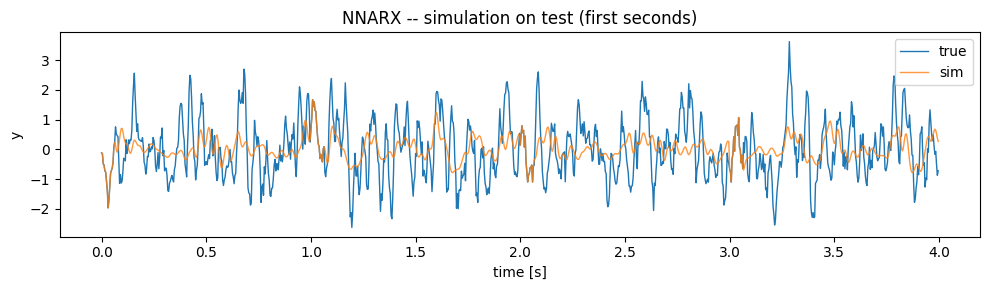


--- NNARX dilated medium ---
ep   2/100  k=1  lr=9.99e-04  train 2.4126e-01  val sim NRMSE 0.9720  (best)
ep   4/100  k=1  lr=9.96e-04  train 2.0619e-01  val sim NRMSE 0.9589  (best)
ep   6/100  k=1  lr=9.91e-04  train 1.9396e-01  val sim NRMSE 0.9523  (best)
ep   8/100  k=1  lr=9.84e-04  train 1.8953e-01  val sim NRMSE 0.9370  (best)
ep  10/100  k=1  lr=9.76e-04  train 1.8690e-01  val sim NRMSE 0.9381  (no improve 1/8)
ep  12/100  k=1  lr=9.65e-04  train 1.8584e-01  val sim NRMSE 0.9259  (best)
ep  14/100  k=1  lr=9.52e-04  train 1.8363e-01  val sim NRMSE 0.9252  (best)
  [curriculum] k 1 -> 5: lr=4.73e-04, restored=True
ep  16/100  k=5  lr=4.69e-04  train 5.9847e-01  val sim NRMSE 0.9158  (best)
ep  18/100  k=5  lr=4.61e-04  train 5.9376e-01  val sim NRMSE 0.9169  (no improve 1/8)
ep  20/100  k=5  lr=4.52e-04  train 5.8922e-01  val sim NRMSE 0.9093  (best)
ep  22/100  k=5  lr=4.43e-04  train 5.8336e-01  val sim NRMSE 0.9030  (best)
ep  24/100  k=5  lr=4.32e-04  train 5.7558e-01  val

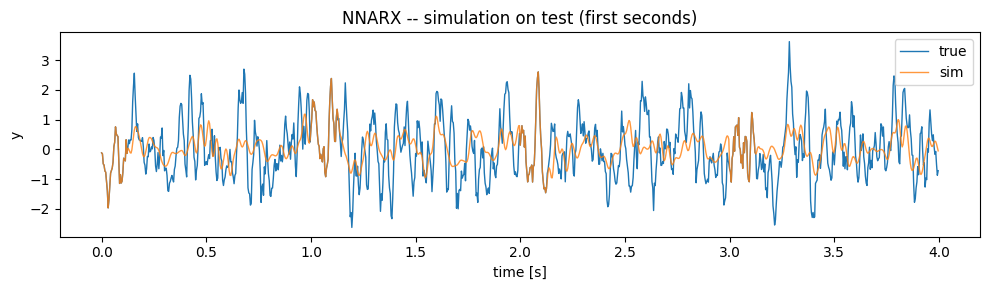


--- NNARX dilated long ---
ep   2/100  k=1  lr=9.99e-04  train 2.7674e-01  val sim NRMSE 0.8803  (best)
ep   4/100  k=1  lr=9.96e-04  train 2.1583e-01  val sim NRMSE 0.8592  (best)
ep   6/100  k=1  lr=9.91e-04  train 2.0195e-01  val sim NRMSE 0.8646  (no improve 1/8)
ep   8/100  k=1  lr=9.84e-04  train 1.9472e-01  val sim NRMSE 0.8748  (no improve 2/8)
ep  10/100  k=1  lr=9.76e-04  train 1.9224e-01  val sim NRMSE 0.8687  (no improve 3/8)
ep  12/100  k=1  lr=9.65e-04  train 1.8966e-01  val sim NRMSE 0.8697  (no improve 4/8)
ep  14/100  k=1  lr=9.52e-04  train 1.8722e-01  val sim NRMSE 0.8661  (no improve 5/8)
  [curriculum] k 1 -> 5: lr=4.73e-04, restored=True
ep  16/100  k=5  lr=4.69e-04  train 6.5269e-01  val sim NRMSE 0.8695  (no improve 1/8)
ep  18/100  k=5  lr=4.61e-04  train 6.3313e-01  val sim NRMSE 0.8598  (no improve 2/8)
ep  20/100  k=5  lr=4.52e-04  train 6.2349e-01  val sim NRMSE 0.8617  (no improve 3/8)
ep  22/100  k=5  lr=4.43e-04  train 6.1465e-01  val sim NRMSE 0.8538  

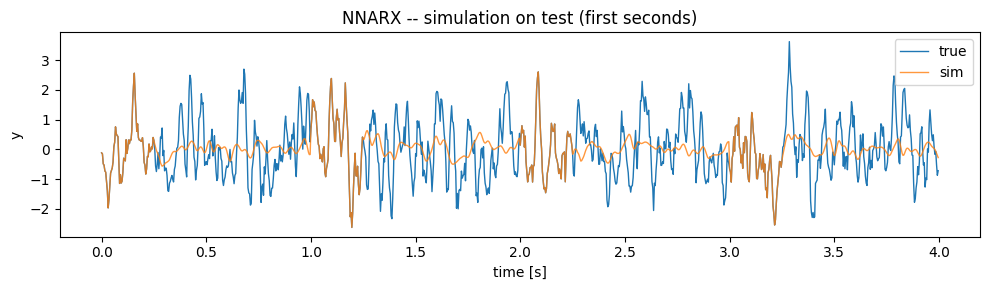


Phase 2 NNARX summary (sorted by sim NRMSE):
NNARX dilated long            NRMSE=0.840  VAF=29.4%  params=5,785  flops=11,440  t=40.0s
NNARX dilated medium          NRMSE=0.895  VAF=19.9%  params=5,590  flops=11,050  t=83.3s
NNARX dilated short           NRMSE=0.930  VAF=13.5%  params=5,395  flops=10,660  t=88.6s
NNARX consec  nu=ny=10        NRMSE=0.968  VAF=6.4%  params=6,240  flops=12,350  t=28.1s
NNARX consec  nu=ny=20        NRMSE=1.010  VAF=-1.9%  params=8,190  flops=16,250  t=91.7s


In [74]:
PHASE2_NARX = []

# (label, u_taps, y_taps). u_taps None / y_taps None => consecutive 0..nu-1 / 1..ny.
configs = [
    ("consec  nu=ny=10",  None,                       None,                    10, 10),
    ("consec  nu=ny=20",  None,                       None,                    20, 20),
    ("dilated short",     (0,1,2,4,8,16),             (1,2,4,8,16),             6,  5),
    ("dilated medium",    (0,1,2,4,8,16,32),          (1,2,4,8,16,32),          7,  6),
    ("dilated long",      (0,1,2,4,8,16,32,64),       (1,2,4,8,16,32,64),       8,  7),
]
for label, ut, yt, nu, ny in configs:
    cfg = dict(CFG)
    cfg["narx_u_taps"] = ut; cfg["narx_y_taps"] = yt
    cfg["narx_nu"]     = nu; cfg["narx_ny"]     = ny
    cfg["epochs_narx"]    = 100
    cfg["narx_ensemble"]  = 1            # single run per sweep point for speed
    cfg["narx_kstep_schedule"] = ((0, 1), (15, 5), (35, 15), (60, 40))
    print(f"\n--- NNARX {label} ---")
    _, res = run_nnarx(cfg)
    res["label"] = label
    PHASE2_NARX.append(res)

print("\nPhase 2 NNARX summary (sorted by sim NRMSE):")
for r in sorted(PHASE2_NARX, key=lambda r: r["nrmse_sim"]):
    print(f"NNARX {r['label']:<22}  "
          f"NRMSE={r['nrmse_sim']:.3f}  VAF={r['vaf_sim']:.1f}%  "
          f"params={r['params']:,}  flops={r['flops_per_sample']:,}  "
          f"t={r['train_time_s']:.1f}s")

## 13. Phase 3 — Comparison across model families

Head-to-head table and a simple params-vs-accuracy scatter.

model        params    flops/smp t_train[s]    NRMSE   VAF[%]
NNARX         5,785       34,320      147.6    0.814    33.82
RNN           4,353        8,513        0.4    1.004    -0.87
LSTM         17,217       33,985        0.4    0.993     1.47
GRU          12,929       25,473        0.4    0.992     1.66

saved: results/phase1_metrics.json


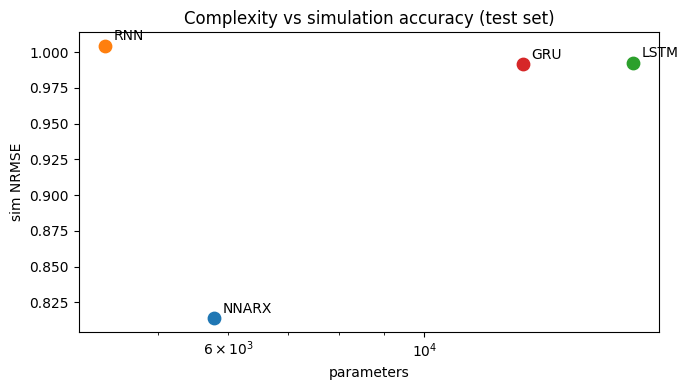

In [75]:
rows = []
for key in ("nnarx", "rnn", "lstm", "gru"):
    if key not in RESULTS: continue
    r = RESULTS[key]
    rows.append([r["model"], r["params"], r["flops_per_sample"], r["train_time_s"],
                 r["nrmse_sim"], r["vaf_sim"]])

print(f"{'model':<8} {'params':>10} {'flops/smp':>12} {'t_train[s]':>10} {'NRMSE':>8} {'VAF[%]':>8}")
for name, p, f, t, n, v in rows:
    print(f"{name:<8} {p:>10,} {f:>12,} {t:>10.1f} {n:>8.3f} {v:>8.2f}")

Path("results").mkdir(exist_ok=True)
with open("results/phase1_metrics.json", "w") as out:
    json.dump({k: {kk: vv for kk, vv in v.items() if kk != "history"}
               for k, v in RESULTS.items()}, out, indent=2)
print("\nsaved: results/phase1_metrics.json")

fig, ax = plt.subplots(figsize=(7, 4))
for name, params, _flops, _t, n, _v in rows:
    ax.scatter(params, n, s=80)
    ax.annotate(name, (params, n), xytext=(6, 4), textcoords="offset points")
ax.set_xscale("log"); ax.set_xlabel("parameters"); ax.set_ylabel("sim NRMSE")
ax.set_title("Complexity vs simulation accuracy (test set)")
plt.tight_layout(); plt.show()

## Next steps

* Extend Phase 2: sweep NNARX `(nu, ny, hidden)` and RNN/GRU sizes; log each run to `results/`.
* Add error-spectrum plot (FFT of `y - ŷ`) — the stimulus is near-periodic, residual spectra are very informative here.
* Cross-check NNARX FLOPs with `ptflops` as a sanity check on the manual formulas.

In [76]:
RUN_LOSO_CV = False

if RUN_LOSO_CV:
    assert CFG["split"] == "loso" and CFG["dataset"] == "medium", \
        "Outer LOSO loop expects dataset='medium', split='loso'."
    fold_rows = []
    for s in range(S):
        cfg = dict(CFG); cfg["loso_test_subject"] = s
        (u_tr, y_tr), (u_va, y_va), (u_te, y_te) = make_loso_split(u_all, y_all, cfg)
        print(f"\n===== LOSO fold: test subject = {s} | "
              f"train {u_tr.shape}, val {u_va.shape}, test {u_te.shape} =====")
        _, r_narx = run_nnarx(cfg, tag=f"nnarx_s{s}")
        _, r_rnn  = run_seq("rnn",  cfg)
        _, r_lstm = run_seq("lstm", cfg)
        _, r_gru  = run_seq("gru",  cfg)
        for r in (r_narx, r_rnn, r_lstm, r_gru):
            fold_rows.append({"fold": s, **{k: v for k, v in r.items() if k != "history"}})

    import statistics as stats
    print("\nLOSO summary (mean ± std across folds):")
    by_model = {}
    for row in fold_rows:
        by_model.setdefault(row["model"], []).append(row)
    for name, rows in by_model.items():
        nr = [r["nrmse_sim"] for r in rows]
        vf = [r["vaf_sim"]   for r in rows]
        print(f"  {name:<6}  NRMSE {stats.mean(nr):.3f} ± {stats.pstdev(nr):.3f}  "
              f"VAF {stats.mean(vf):.2f} ± {stats.pstdev(vf):.2f}%")

    Path("results").mkdir(exist_ok=True)
    with open("results/loso_folds.json", "w") as f:
        json.dump(fold_rows, f, indent=2)
    print("\nsaved: results/loso_folds.json")
else:
    print("RUN_LOSO_CV=False — single-fold only. Set True to run all S folds.")

RUN_LOSO_CV=False — single-fold only. Set True to run all S folds.


## Next steps

* Leave-one-subject-out split — re-run with participant-level holdout for a stronger generalization check.
* Extend Phase 2: sweep NNARX `(nu, ny, hidden)` and RNN/GRU sizes; log each run to `results/`.
* Add error-spectrum plot (FFT of `y - ŷ`) — the stimulus is near-periodic, residual spectra are very informative here.
* Cross-check NNARX FLOPs with `ptflops` as a sanity check on the manual formulas.
